In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from utils import N, print_decorated;

Генерація рівномірного проміжку $(0; 1)$ і перетворення на експоненційний розподіл за допомогою формули $x_i = -\frac{1}{\lambda} \ln \xi_i$

In [2]:
def generate_exponential_data(lambd, size):
    xi = np.random.uniform(1e-10, 1.0, size=size)
    return -(1 / lambd) * np.log(xi)

Обчислення емпіричних та теоретичних значень середнього $E[X]=\frac{1}{\lambda}$ і дисперсії $Var[X]=\frac{1}{\lambda^2}$

In [3]:
def calculate_statistics(x, lambd):
    mean_emp = np.mean(x)
    var_emp = np.var(x, ddof=1)
    mean_theor = 1 / lambd
    var_theor = 1 / (lambd**2)
    return mean_emp, var_emp, mean_theor, var_theor

Оцінка узгодженості даних із законами розподілу за критерієм Пірсона $\chi^2=\sum \frac{(O_i-E_i)^2}{E_i}$ та $p_{value}$

In [4]:
def perform_chi2_test(x, lambd, k_bins, N):
    counts, bin_edges = np.histogram(x, bins=k_bins)
    cdf = lambda val: 1 - np.exp(-lambd * val)
    
    prob = np.diff(cdf(bin_edges))
    expected_counts = prob * N
    expected_counts[-1] += (1 - cdf(bin_edges[-1])) * N
    
    chi2_stat = np.sum((counts - expected_counts) ** 2 / expected_counts)
    df = k_bins - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)
    
    return chi2_stat, p_value

Побудова нормалізованої гістограми та теоретичної кривої щільності ймовірності

In [8]:
def plot_all_distributions(lambd_values, get_data_func, k_bins, N):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    
    for i, lambd in enumerate(lambd_values):
        x = get_data_func(lambd, N)
        
        ax = axes[i]
        ax.hist(x, bins=k_bins, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Гістограма")
        
        x_vals = np.linspace(0, np.max(x), 200)
        ax.plot(x_vals, lambd * np.exp(-lambd * x_vals), "r-", label=f"Теор. PDF (λ={lambd})")
        
        ax.set_title(f"Експоненційний розподіл (λ = {lambd})")
        ax.set_xlabel("x")
        ax.set_ylabel("Густина")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

Головна функція для виконання першого завдання


Генерація експоненційного розподілу

Параметр lambda = 0.5:
Середнє:  емпіричне = 1.9614, теоретичне = 2.0000
Дисперсія: емпірична = 3.9246, теоретична = 4.0000
Хі-квадрат: stat = 18.2956, p-value = 0.5028
Гіпотеза про експоненційний розподіл ПРИЙМАЄТЬСЯ (p > alpha)

Параметр lambda = 1.0:
Середнє:  емпіричне = 0.9947, теоретичне = 1.0000
Дисперсія: емпірична = 0.9781, теоретична = 1.0000
Хі-квадрат: stat = 18.4932, p-value = 0.4898
Гіпотеза про експоненційний розподіл ПРИЙМАЄТЬСЯ (p > alpha)

Параметр lambda = 2.0:
Середнє:  емпіричне = 0.5028, теоретичне = 0.5000
Дисперсія: емпірична = 0.2512, теоретична = 0.2500
Хі-квадрат: stat = 19.9041, p-value = 0.4004
Гіпотеза про експоненційний розподіл ПРИЙМАЄТЬСЯ (p > alpha)

Параметр lambda = 5.0:
Середнє:  емпіричне = 0.1959, теоретичне = 0.2000
Дисперсія: емпірична = 0.0376, теоретична = 0.0400
Хі-квадрат: stat = 20.7629, p-value = 0.3500
Гіпотеза про експоненційний розподіл ПРИЙМАЄТЬСЯ (p > alpha)


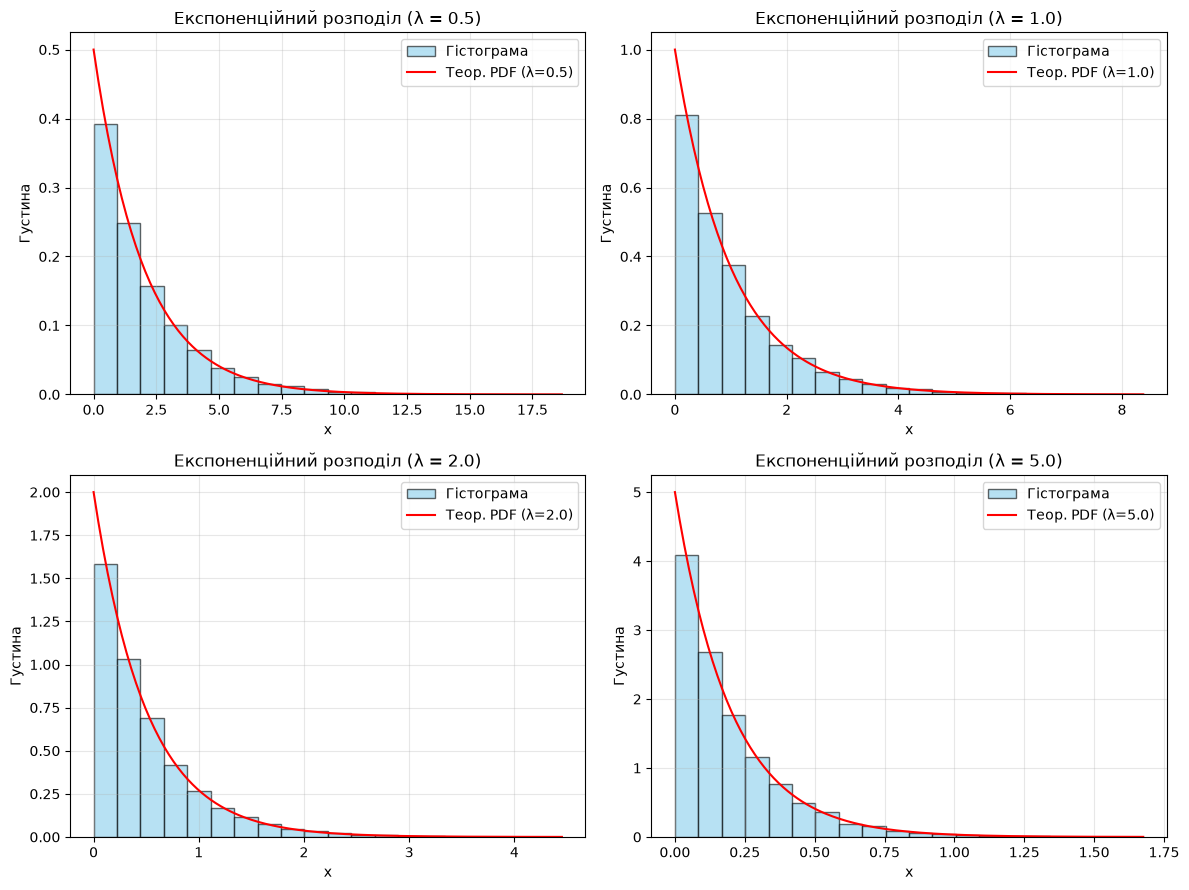

In [15]:
def task_1_exponential(lambd_values=[0.5, 1.0, 2.0, 5.0], k_bins=20, alpha=0.05):
    print_decorated("Генерація експоненційного розподілу", 10)

    for lambd in lambd_values:
        x = generate_exponential_data(lambd, N)
        mean_emp, var_emp, mean_theor, var_theor = calculate_statistics(x, lambd)
        
        print(f"\nПараметр lambda = {lambd}:")
        print(f"Середнє:  емпіричне = {mean_emp:.4f}, теоретичне = {mean_theor:.4f}")
        print(f"Дисперсія: емпірична = {var_emp:.4f}, теоретична = {var_theor:.4f}")

        chi2_stat, p_value = perform_chi2_test(x, lambd, k_bins, N)
        
        print(f"Хі-квадрат: stat = {chi2_stat:.4f}, p-value = {p_value:.4f}")
        if p_value > alpha:
            print("Гіпотеза про експоненційний розподіл ПРИЙМАЄТЬСЯ (p > alpha)")
        else:
            print("Гіпотеза ВІДХИЛЯЄТЬСЯ (p <= alpha)")

    plot_all_distributions(lambd_values, generate_exponential_data, k_bins, N)

if __name__ == "__main__":
    task_1_exponential()